In [1]:
import os
print("Current Working Directory:")
print(os.getcwd())

import os

os.chdir(r"C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis")

print(os.getcwd())
print(os.listdir("data"))

Current Working Directory:
c:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis\clustering
C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis
['train.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Load and Preprocess
df = pd.read_csv('data/train.csv')
df_model = df.drop(columns=['Employee_Id'])

# Encoding categorical columns
le = LabelEncoder()
df_model['Work_Life_Balance'] = le.fit_transform(df_model['Work_Life_Balance'])
df_model['Lives_With_Family'] = le.fit_transform(df_model['Lives_With_Family'])
df_model = pd.get_dummies(df_model, columns=['Work_From', 'Working_State'])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model.drop(columns=['Stress_Level']))

# Hierarchical Model (3 clusters for Low, Moderate, High)
hierarchical = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['Cluster'] = hierarchical.fit_predict(X_scaled)

# Evaluation Metrics
print(f"Silhouette Score: {silhouette_score(X_scaled, df['Cluster']):.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, df['Cluster']):.4f}")

Silhouette Score: 0.1157
Davies-Bouldin Index: 2.5949


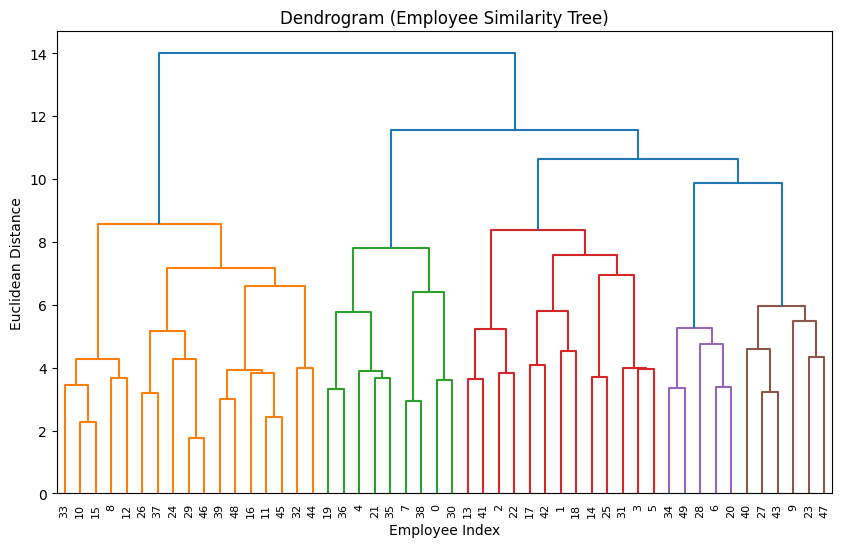

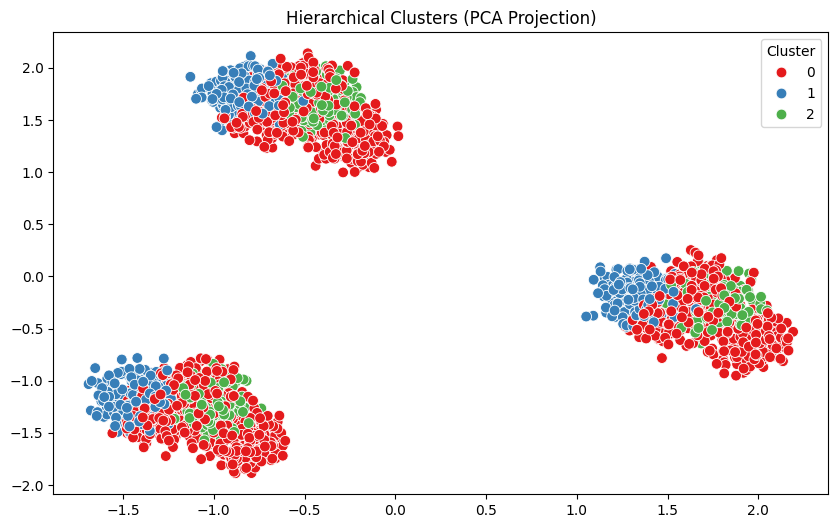

In [3]:
# --- 1. Dendrogram Plot ---
# We sample 50 points to ensure the tree is readable
X_sample = X_scaled[np.random.choice(X_scaled.shape[0], 50, replace=False)]
Z = linkage(X_sample, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title('Dendrogram (Employee Similarity Tree)')
plt.xlabel('Employee Index')
plt.ylabel('Euclidean Distance')
plt.show()

# --- 2. Cluster Plot (PCA) ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='Set1', s=60)
plt.title('Hierarchical Clusters (PCA Projection)')
plt.show()